In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcZGFuaWVcRGVza3RvcFxGdXp6eVB5U2VnXGV4YW1wbGU='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\ProgramData\\anaconda3\\Lib\\importlib\\_bootstrap.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\importlib\\_bootstrap_external.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\zipimport.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\codecs.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\encodings\\aliases.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\encodings\\__init__.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\encodings\\utf_8.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\encodings\\cp1252.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\abc.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\io.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\stat.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\_collections_abc.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\genericpath.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\ntpath.py": 1712650154.0, "C:\\ProgramData\\anaconda3\\Lib\\os.py": 1712650154.0, "C:\\Prog

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import sys
import matplotlib as mpl

mpl.rcParams['figure.figsize'] = (8, 5)
mpl.rcParams['font.size'] = 13

# Add parent directory to path to import FuzzyPySeg
sys.path.insert(0, os.path.abspath('..'))
from FuzzyPySeg import FCM

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

Image shape: (640, 640, 3)
Image mode: RGB


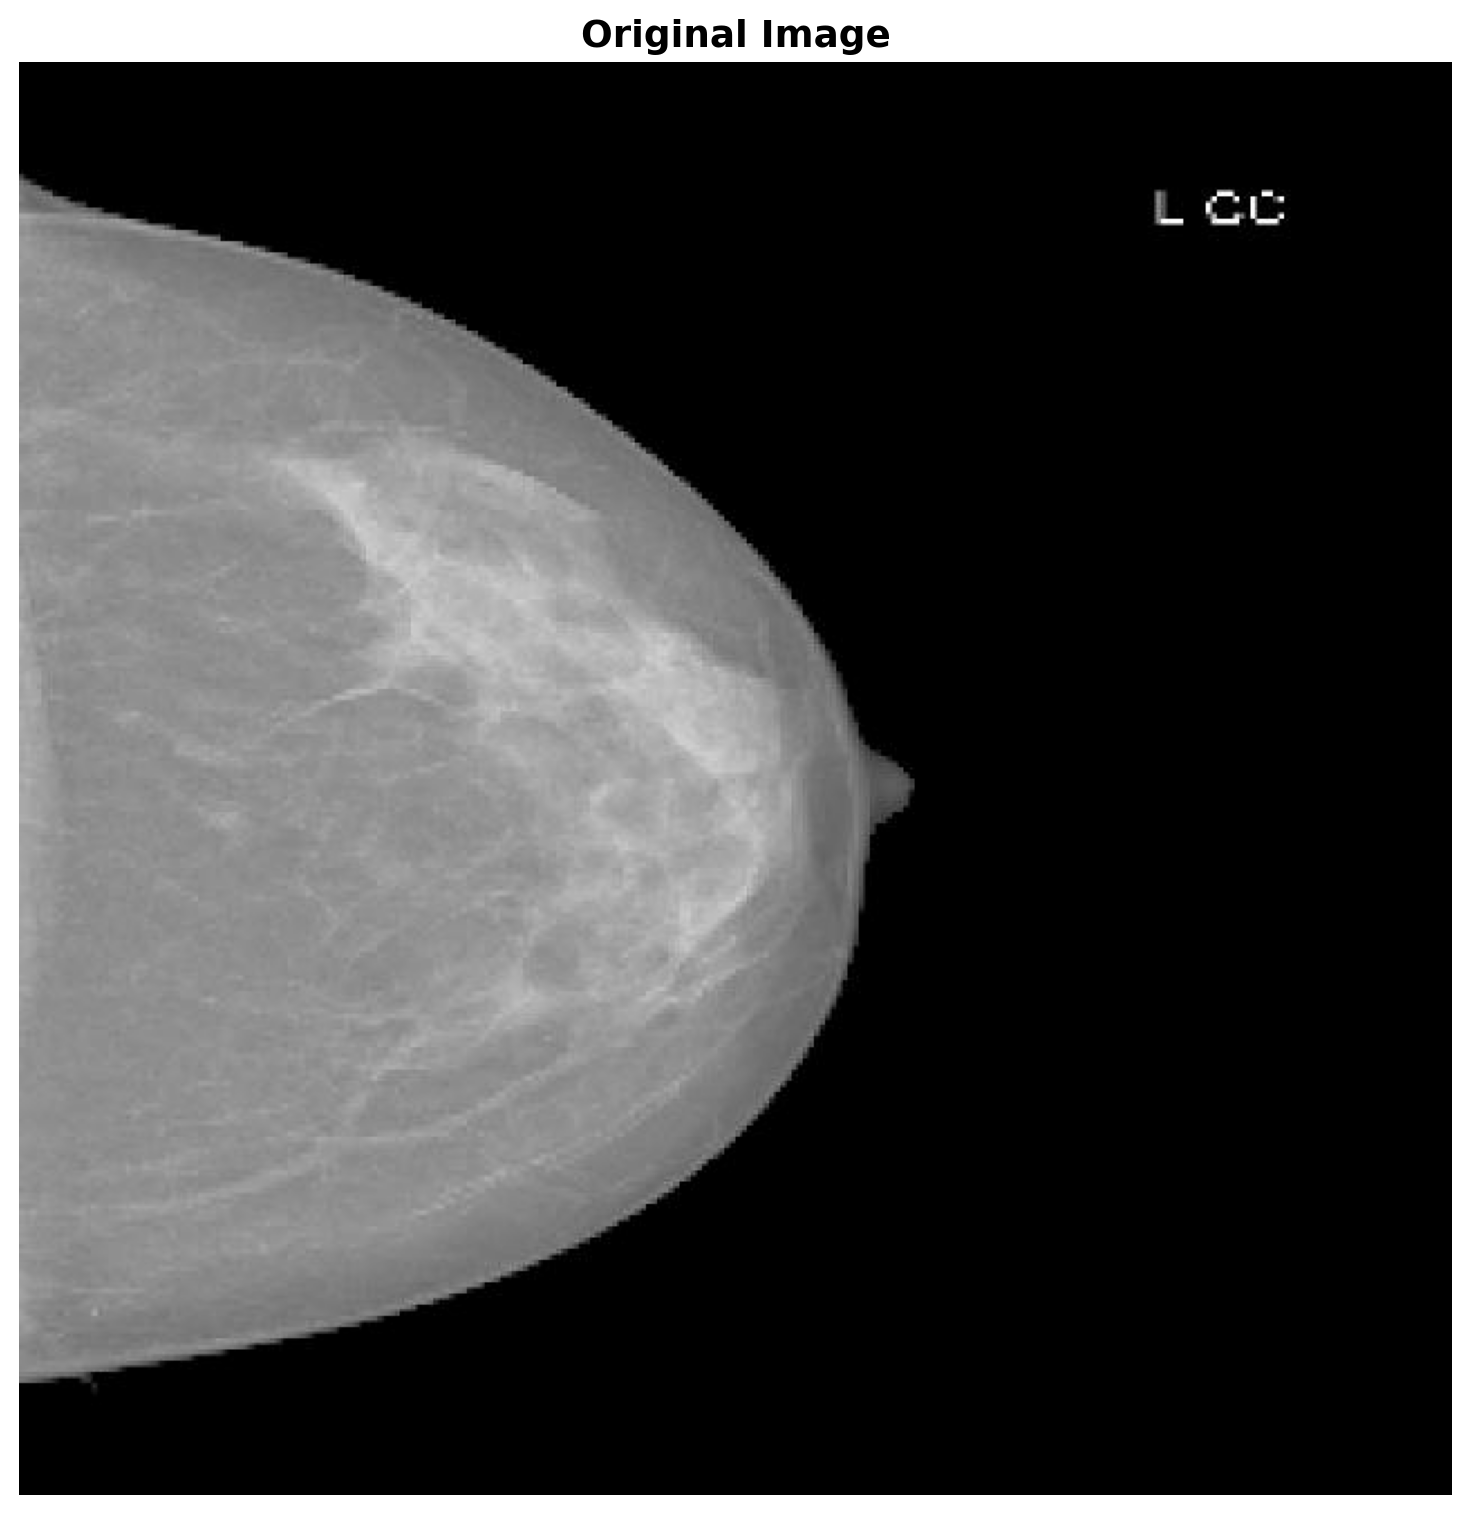

In [3]:
# Load the example image
image_path = 'example.jpg'

# Check if image exists
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Please place an example image named 'example.jpg' in the example folder")

# Load and display the original image
original_image = Image.open(image_path)
original_array = np.array(original_image)

print(f"Image shape: {original_array.shape}")
print(f"Image mode: {original_image.mode}")

# Display the original image
plt.figure(figsize=(10, 8))
plt.imshow(original_array)
plt.title('Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
import random
import logging

# Suppress INFO level logging from FCM
logging.basicConfig(level=logging.WARNING)

np.random.seed(42)  
random.seed(42)     

output_dir_euclidean = 'output_euclidean'
output_dir_mahalanobis = 'output_mahalanobis'
os.makedirs(output_dir_euclidean, exist_ok=True)
os.makedirs(output_dir_mahalanobis, exist_ok=True)

num_clusters = 3
fuzziness = 2
max_iterations = 50
centroid_init = "GA"  
error_threshold = 0.001
fuzzy_clustering = "False" 

FCM(
    image_path=image_path,
    save_to_path=output_dir_euclidean,
    numClust=num_clusters,
    m=fuzziness,
    maxIter=max_iterations,
    clusterMethod="Euclidean",
    centroid_init=centroid_init,
    error=error_threshold,
    hard=fuzzy_clustering
)

FCM(
    image_path=image_path,
    save_to_path=output_dir_mahalanobis,
    numClust=num_clusters,
    m=fuzziness,
    maxIter=max_iterations,
    clusterMethod="Mahalanobis",
    centroid_init=centroid_init,
    error=error_threshold,
    hard=fuzzy_clustering
)

In [5]:
def plot_single_clustering(output_dir, num_clusters, method_name, method_description, filename_suffix=""):
    """
    Load and display a single clustering result.
    
    Parameters:
    -----------
    output_dir : str
        Path to directory containing the clustering results
    num_clusters : int
        Number of clusters used in the segmentation
    method_name : str
        Name of the method (e.g., "Euclidean Distance")
    method_description : str
        Description of the method (e.g., "Spherical Clusters")
    filename_suffix : str
        Optional suffix for the filename (e.g., "_M" for Mahalanobis)
    """
    # Load the overlayed color image
    overlay_path = os.path.join(output_dir, f'group{num_clusters}_FCM{filename_suffix}.jpeg')
    
    # Load result
    if os.path.exists(overlay_path):
        overlay_image = Image.open(overlay_path)
        overlay_array = np.array(overlay_image)
        loaded = True
    else:
        print(f"Warning: {overlay_path} not found")
        loaded = False
    
    # Display result
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    if loaded:
        ax.imshow(overlay_array)
        ax.set_title(f'{method_name}\n({method_description})', fontsize=14, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'{method_name} result\nnot found', 
                ha='center', va='center', fontsize=12)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

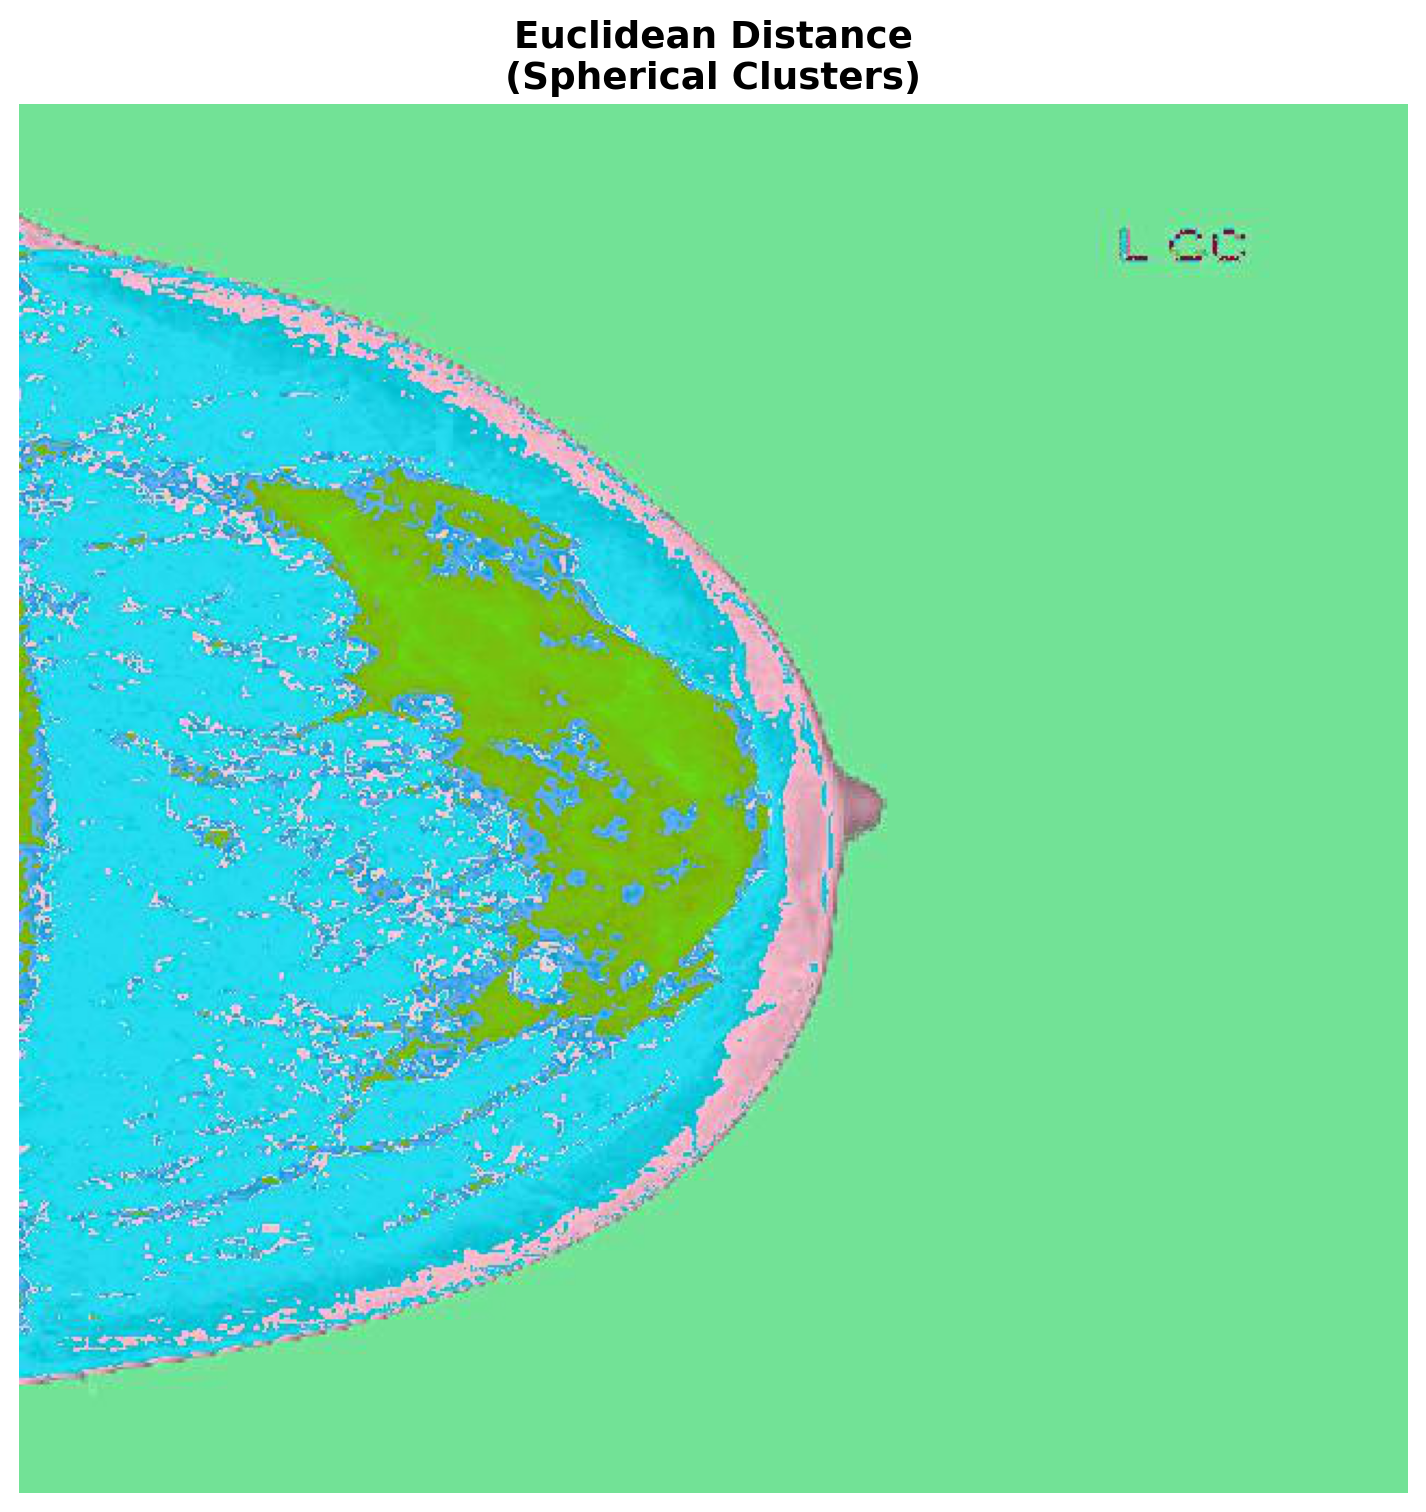

In [6]:
#| out-width: 100%
# Display Euclidean clustering result
plot_single_clustering(output_dir_euclidean, num_clusters, 
                       "Euclidean Distance", "Spherical Clusters")

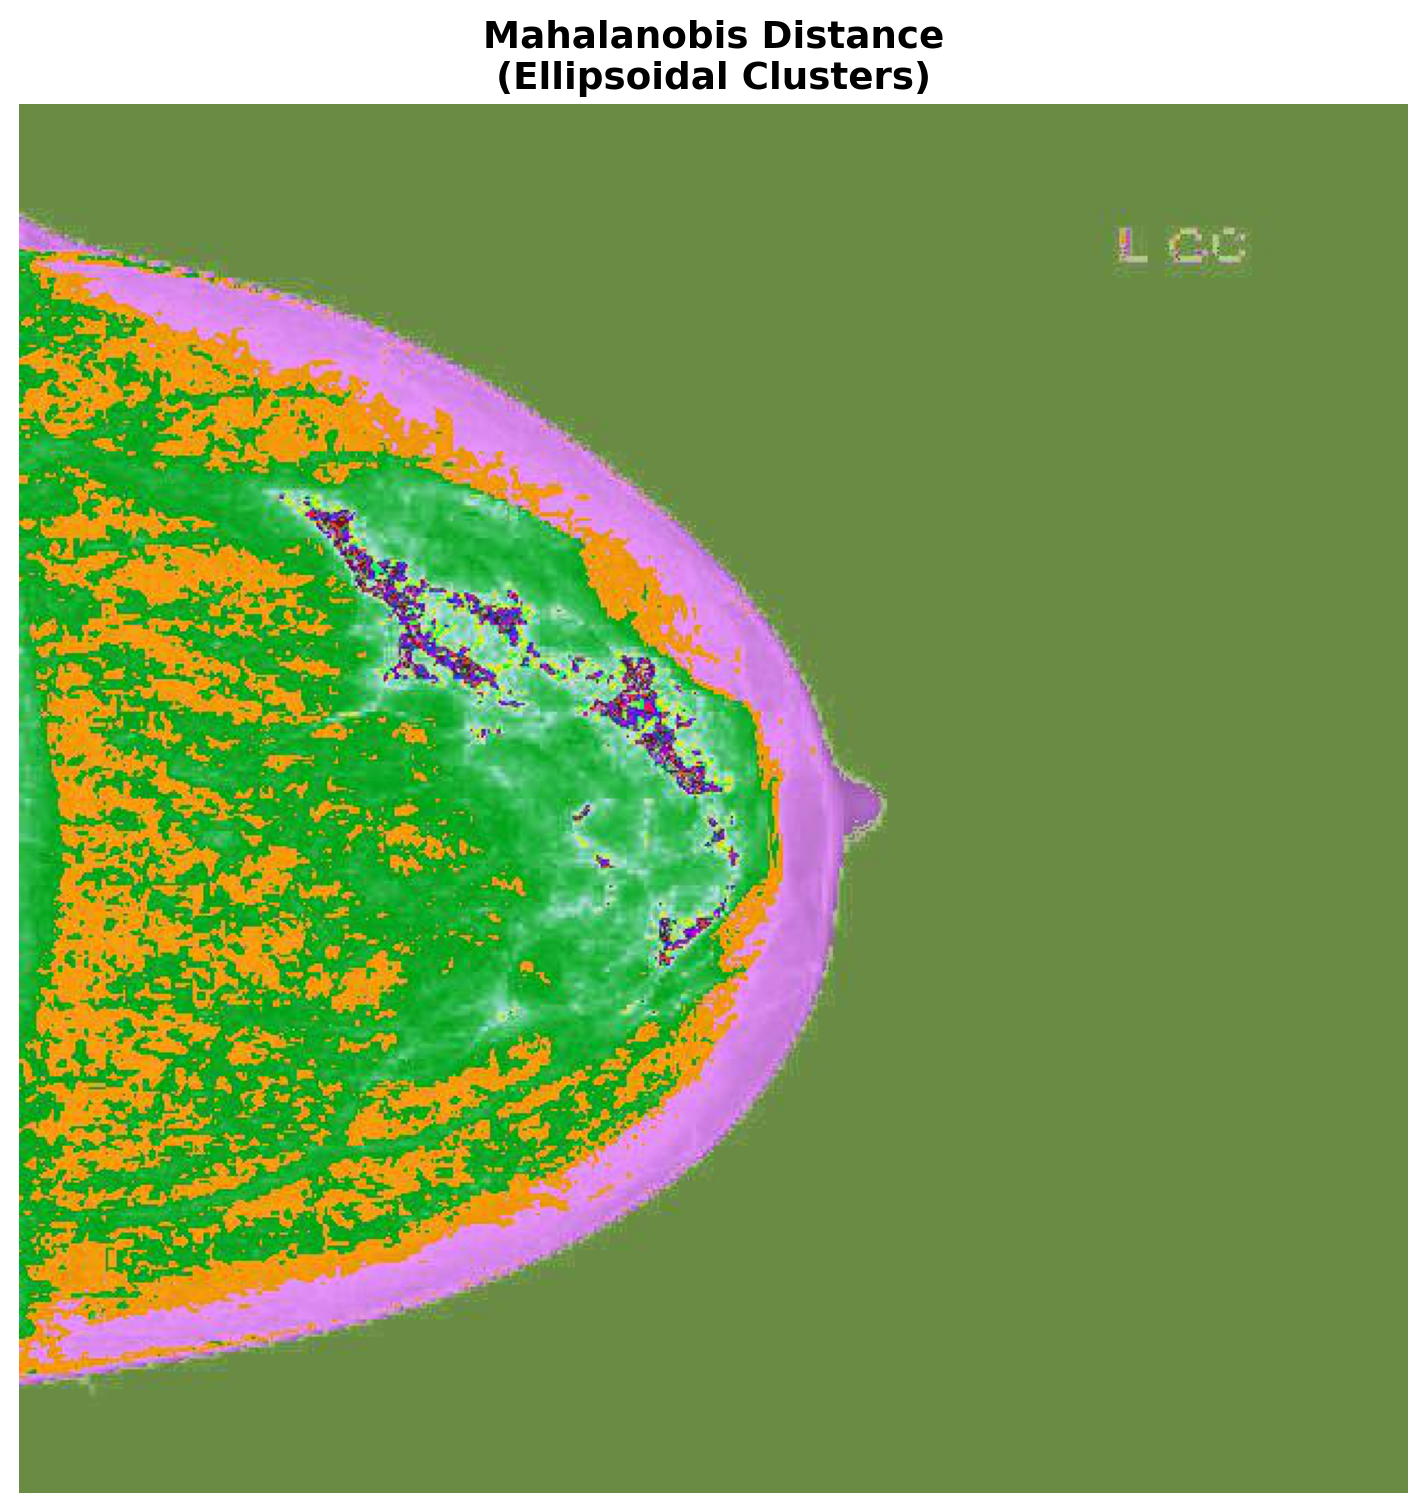

In [7]:
#| out-width: 100%
# Display Mahalanobis clustering result
plot_single_clustering(output_dir_mahalanobis, num_clusters, 
                       "Mahalanobis Distance", "Ellipsoidal Clusters", 
                       filename_suffix="_M")

In [8]:
#| out-width: 100%
# Set random seeds for reproducibility
import random
import logging

# Suppress INFO level logging from FCM
logging.basicConfig(level=logging.WARNING)

np.random.seed(42)  # Set numpy random seed
random.seed(42)     # Set Python random seed

# Set up output directories for each method
output_dir_euclidean = 'output_euclidean'
output_dir_mahalanobis = 'output_mahalanobis'
os.makedirs(output_dir_euclidean, exist_ok=True)
os.makedirs(output_dir_mahalanobis, exist_ok=True)

# Parameters for segmentation
num_clusters = 3
fuzziness = 2
max_iterations = 50
centroid_init = "GA"  # Using Genetic Algorithm for both methods
error_threshold = 0.001
fuzzy_clustering = "True"  # "False" means soft/fuzzy clustering

print("="*60)
print("Running Fuzzy C-Means segmentation with fuzzy clustering")
print("="*60)
print(f"\nCommon parameters:")
print(f"  - Number of clusters: {num_clusters}")
print(f"  - Fuzziness parameter (m): {fuzziness}")
print(f"  - Maximum iterations: {max_iterations}")
print(f"  - Centroid initialization: {centroid_init} (Genetic Algorithm)")
print(f"  - Fuzzy clustering: Enabled (soft clustering)")

# Run Euclidean distance segmentation
print(f"\n{'='*60}")
print("Running with EUCLIDEAN distance...")
print(f"{'='*60}")
FCM(
    image_path=image_path,
    save_to_path=output_dir_euclidean,
    numClust=num_clusters,
    m=fuzziness,
    maxIter=max_iterations,
    clusterMethod="Euclidean",
    centroid_init=centroid_init,
    error=error_threshold,
    hard=fuzzy_clustering
)
print("✓ Euclidean segmentation complete!")

# Run Mahalanobis distance segmentation
print(f"\n{'='*60}")
print("Running with MAHALANOBIS distance...")
print(f"{'='*60}")
FCM(
    image_path=image_path,
    save_to_path=output_dir_mahalanobis,
    numClust=num_clusters,
    m=fuzziness,
    maxIter=max_iterations,
    clusterMethod="Mahalanobis",
    centroid_init=centroid_init,
    error=error_threshold,
    hard=fuzzy_clustering
)
print("✓ Mahalanobis segmentation complete!")

print(f"\n{'='*60}")
print("Both segmentations complete!")
print(f"  - Euclidean results: {output_dir_euclidean}/")
print(f"  - Mahalanobis results: {output_dir_mahalanobis}/")
print(f"{'='*60}")

Running Fuzzy C-Means segmentation with fuzzy clustering

Common parameters:
  - Number of clusters: 3
  - Fuzziness parameter (m): 2
  - Maximum iterations: 50
  - Centroid initialization: GA (Genetic Algorithm)
  - Fuzzy clustering: Enabled (soft clustering)

Running with EUCLIDEAN distance...


✓ Euclidean segmentation complete!

Running with MAHALANOBIS distance...


✓ Mahalanobis segmentation complete!

Both segmentations complete!
  - Euclidean results: output_euclidean/
  - Mahalanobis results: output_mahalanobis/


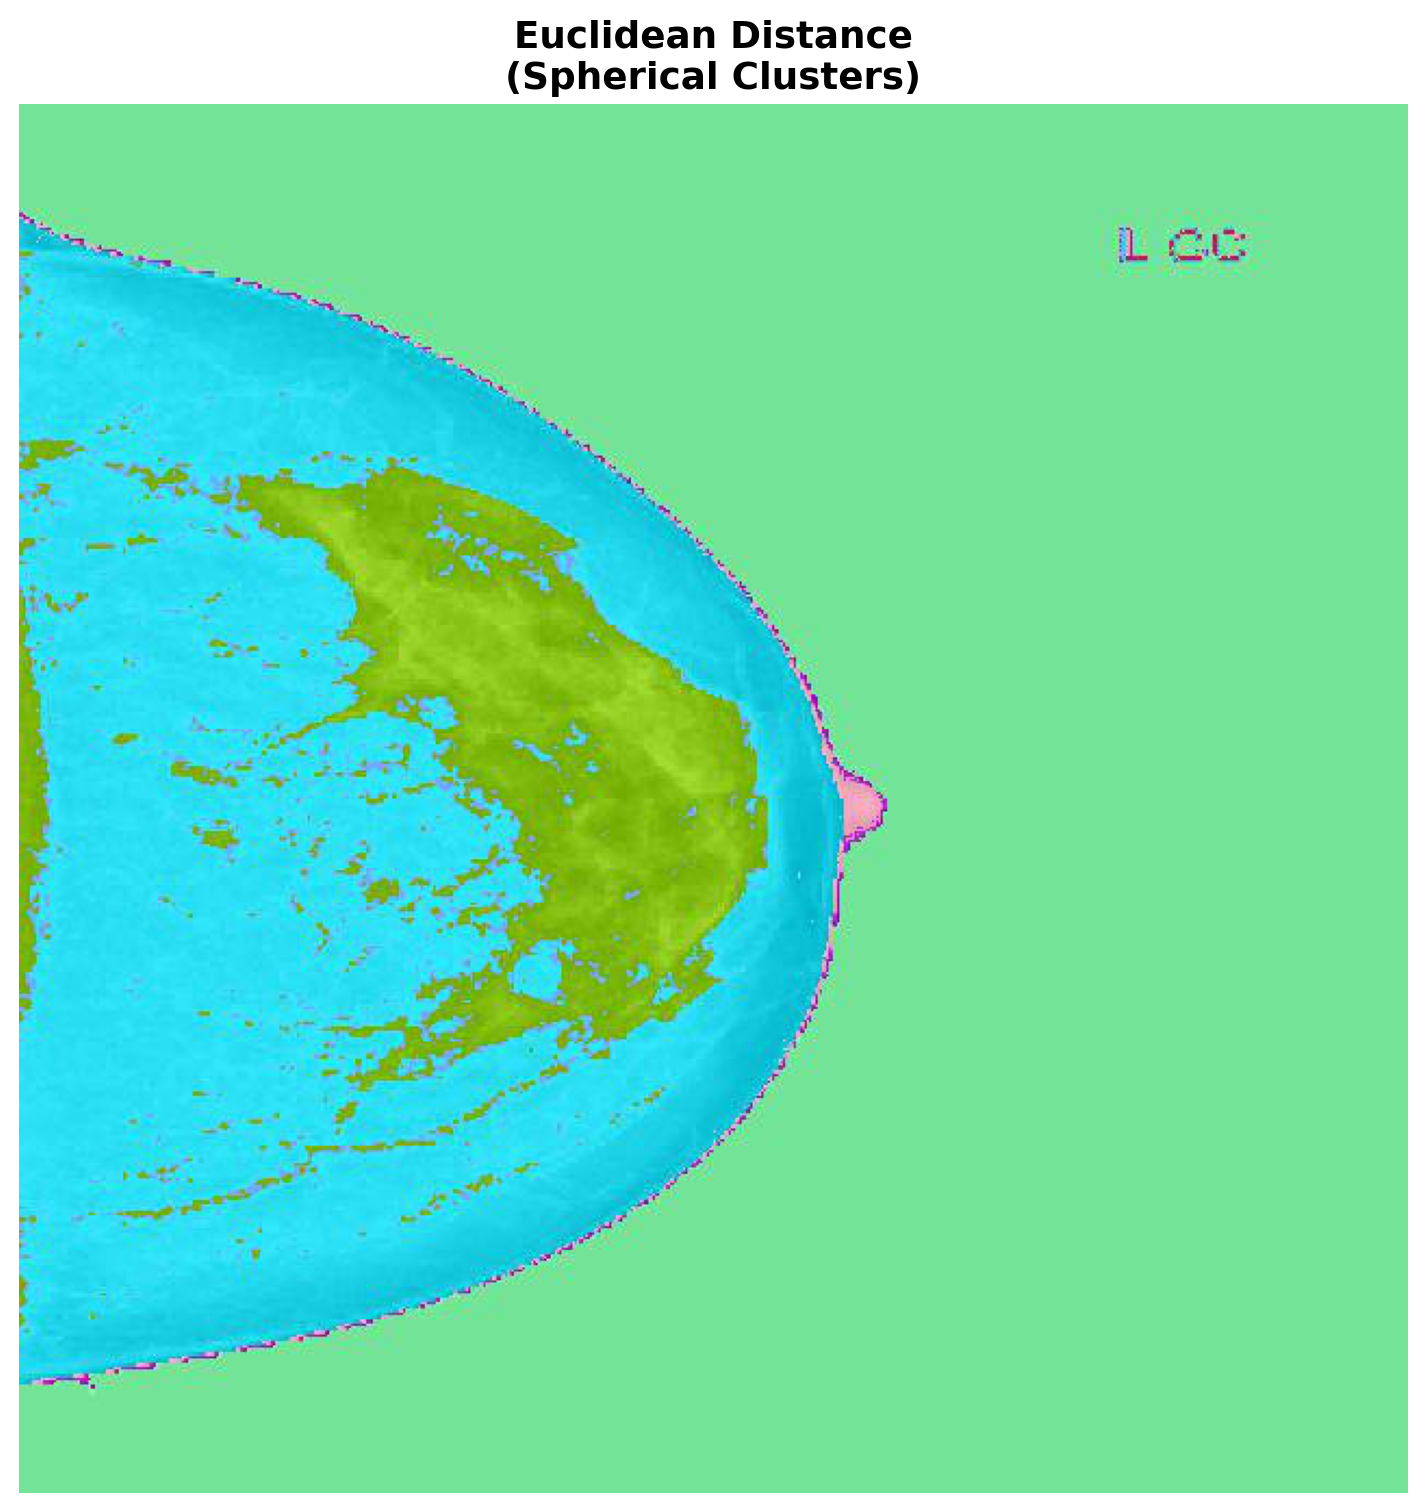

In [9]:
#| out-width: 100%
# Display Euclidean clustering result
plot_single_clustering(output_dir_euclidean, num_clusters, 
                       "Euclidean Distance", "Spherical Clusters")

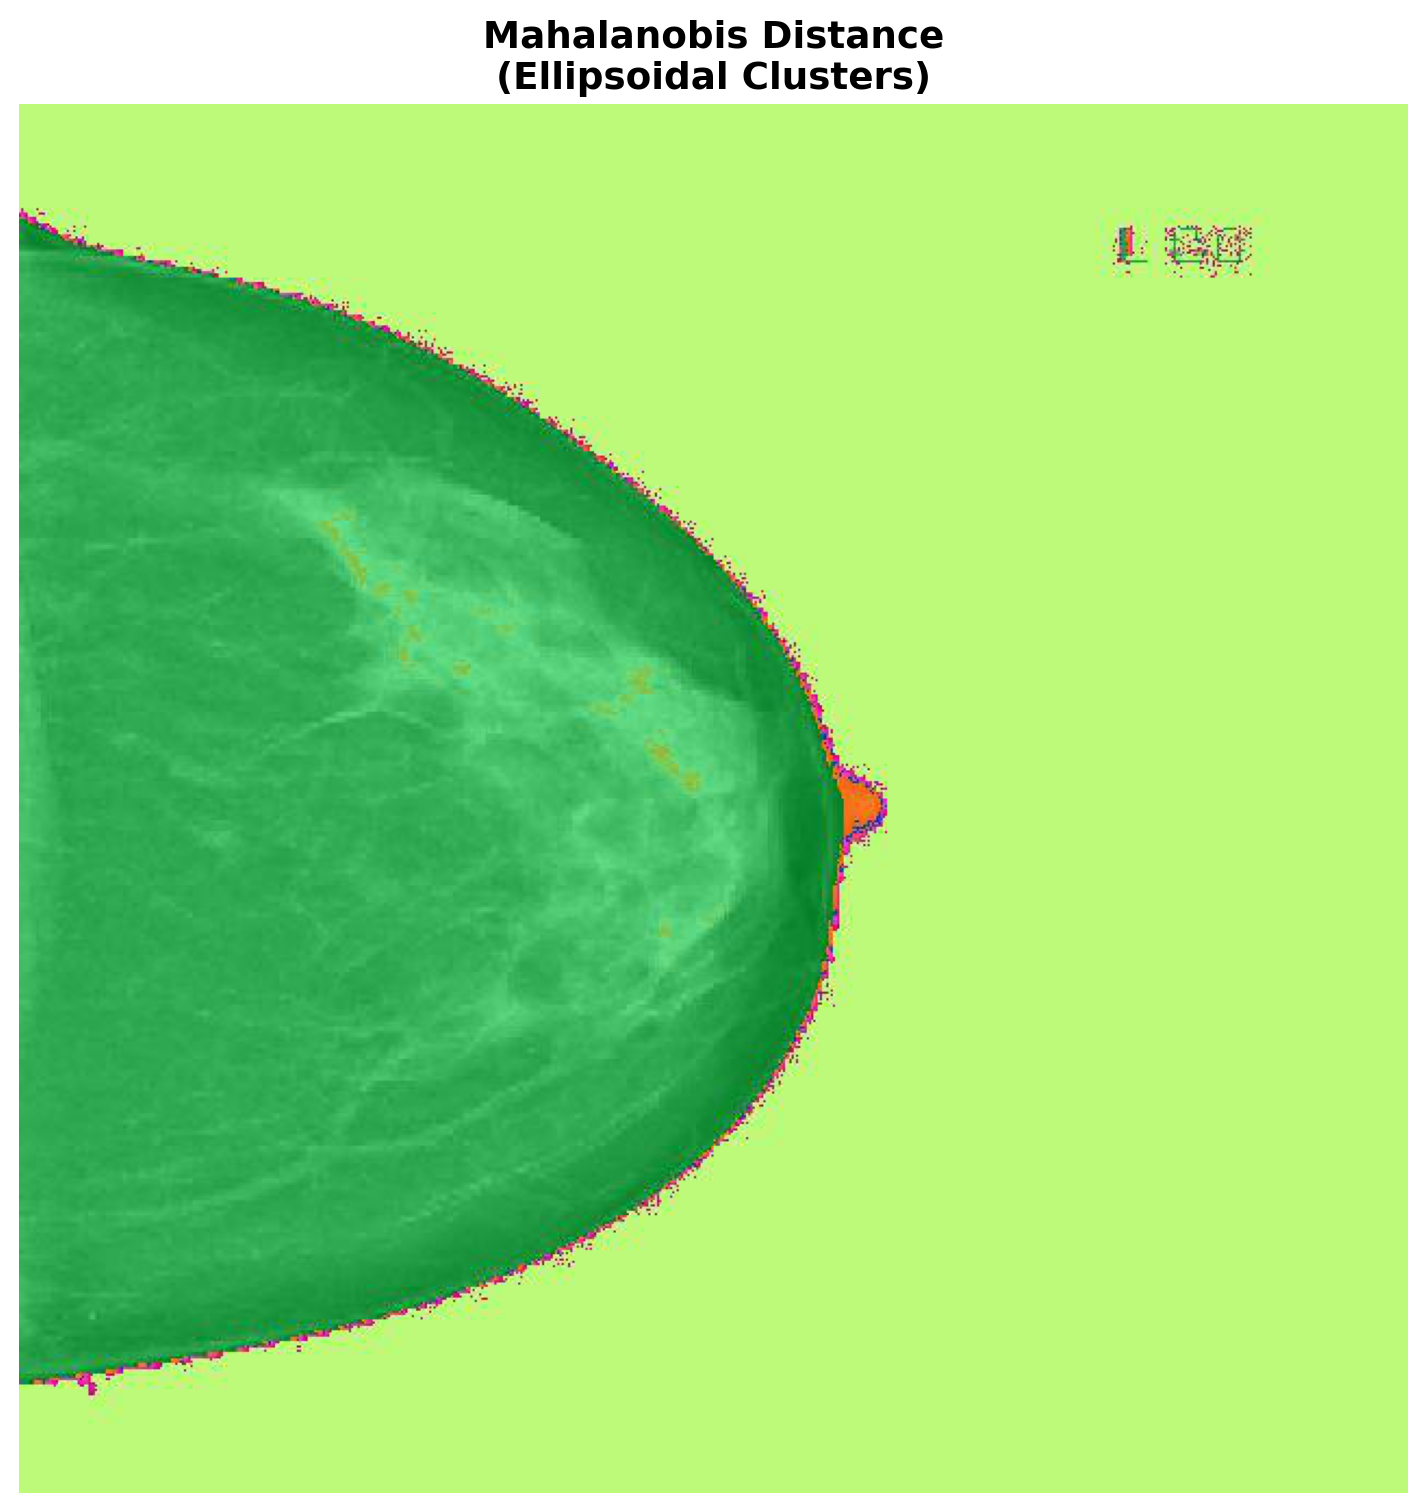

In [10]:
#| out-width: 100%
# Display Mahalanobis clustering result
plot_single_clustering(output_dir_mahalanobis, num_clusters, 
                       "Mahalanobis Distance", "Ellipsoidal Clusters", 
                       filename_suffix="_M")